# Digit Classification Pipeline (k-NN + ANN)

This notebook uses MNIST from `torchvision` and evaluates feature extraction with k-NN and ANN models.

## Goals
- Use a dataset from a library/framework.
- Keep the same workflow: feature extraction + k-NN + neural network.
- Fix issues from the earlier version (hardcoded loops, multiclass logic, reproducibility).
- Add evaluation plots and model comparison.


## Changes From The Previous Notebook

- Replaced CSV generation/indexing logic with direct in-memory dataset splits.
- Replaced custom Hu formulas with OpenCV Hu moments (`cv.HuMoments`).
- Removed hardcoded feature-length assumptions.
- Removed interactive `input()` prompts and used explicit config values.
- Fixed multiclass ANN prediction (`argmax`, not thresholding).
- Added deterministic seeds and stratified per-class splits.
- Added validation-based model selection and test reporting.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from digit_pipeline import (
    ExperimentConfig,
    Standardizer,
    classification_report_from_cm,
    evaluate_knn_grid,
    evaluate_mlp,
    extract_features,
    get_device,
    load_splits,
    plot_class_distribution,
    plot_confusion_matrix,
    plot_knn_grid,
    plot_learning_curves,
    plot_model_comparison,
    plot_sample_grid,
    set_seed,
    train_mlp,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", 20)

config = ExperimentConfig(
    seed=42,
    data_root="/data",
    train_per_class=700,
    val_per_class=100,
    test_per_class=200,
    tchebichef_order=3,
    knn_k_values=(3, 5, 7, 11, 15),
    knn_chunk_size=512,
    batch_size=256,
    epochs=25,
    learning_rate=1e-3,
    weight_decay=1e-4,
    hidden_dims=(256, 128),
    dropout=0.2,
    patience=5,
    allow_fake_fallback=False,
)

set_seed(config.seed)
device = get_device()
print(f"Device: {device}")


Device: cuda


## 1) Load Dataset From Framework (`torchvision`)

`MNIST` is downloaded through `torchvision.datasets.MNIST`.
If your runtime has no internet, set `allow_fake_fallback=True` in the config for offline smoke tests.


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.08MB/s]


Dataset source: MNIST (torchvision)
Train: (7000, 28, 28), Val: (1000, 28, 28), Test: (2000, 28, 28)


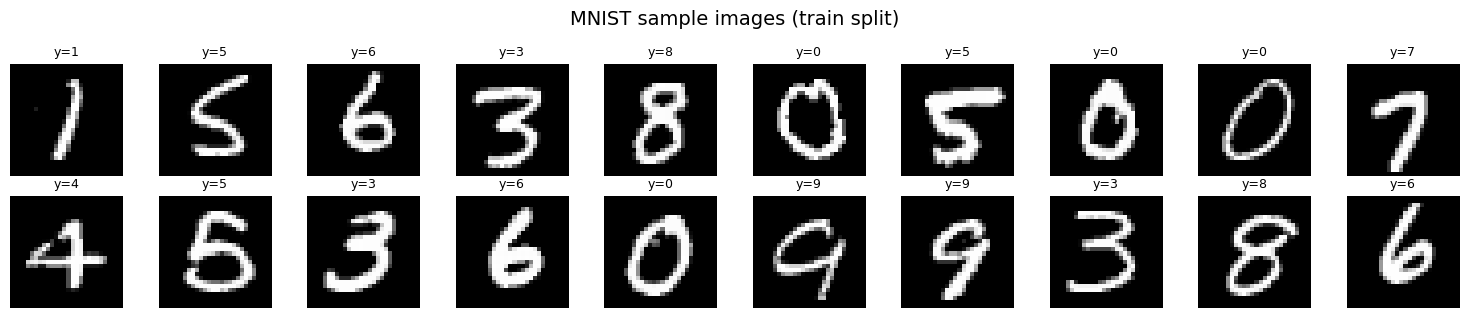

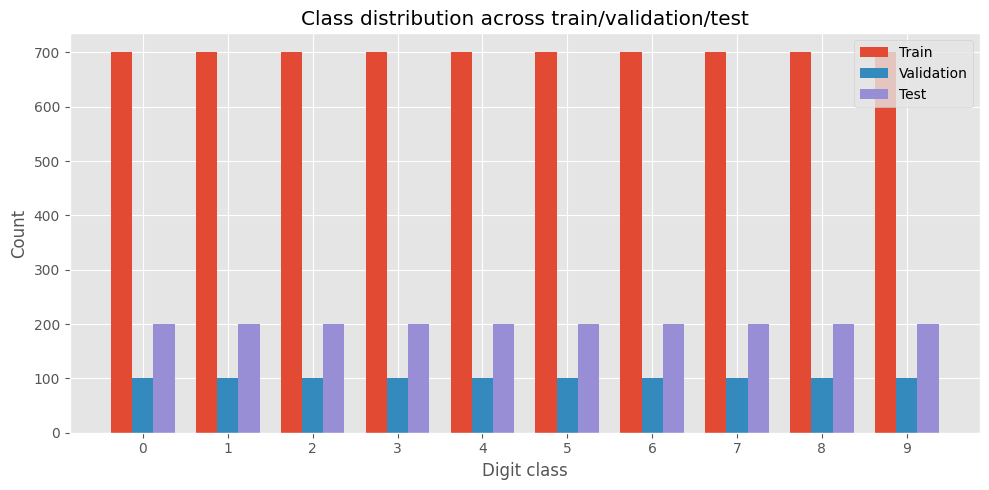

In [6]:
splits = load_splits(config)

print(f"Dataset source: {splits['source']}")
print(
    f"Train: {splits['x_train_img'].shape}, Val: {splits['x_val_img'].shape}, Test: {splits['x_test_img'].shape}"
)

plot_sample_grid(splits["x_train_img"], splits["y_train"], title="MNIST sample images (train split)", n=20)
plot_class_distribution(
    splits["y_train"],
    splits["y_val"],
    splits["y_test"],
    title="Class distribution across train/validation/test",
)


## 2) Feature Extraction

This notebook evaluates three feature families:
- `raw`: flattened normalized pixels.
- `hu`: Hu invariant moments.
- `tchebichef`: Tchebichef moments.

All features are standardized using train-only statistics.


In [7]:
feature_sets = {}

for feature_kind in ["raw", "hu", "tchebichef"]:
    x_train = extract_features(
        splits["x_train_img"], kind=feature_kind, tchebichef_order=config.tchebichef_order
    )
    x_val = extract_features(
        splits["x_val_img"], kind=feature_kind, tchebichef_order=config.tchebichef_order
    )
    x_test = extract_features(
        splits["x_test_img"], kind=feature_kind, tchebichef_order=config.tchebichef_order
    )

    scaler = Standardizer()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_test = scaler.transform(x_test)

    feature_sets[feature_kind] = {
        "x_train": x_train,
        "x_val": x_val,
        "x_test": x_test,
    }

    print(
        f"{feature_kind:10s} -> train {x_train.shape}, val {x_val.shape}, test {x_test.shape}"
    )


raw        -> train (7000, 784), val (1000, 784), test (2000, 784)
hu         -> train (7000, 7), val (1000, 7), test (2000, 7)
tchebichef -> train (7000, 10), val (1000, 10), test (2000, 10)


## 3) k-Nearest Neighbors (Validation Model Selection)



=== k-NN on raw features ===


,k,val_accuracy
0,3,0.900
1,5,0.904
2,7,0.903
3,11,0.903
4,15,0.894


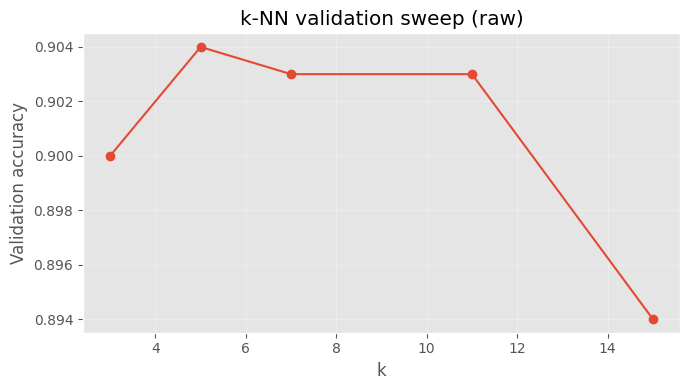


=== k-NN on hu features ===


,k,val_accuracy
0,3,0.446
1,5,0.471
2,7,0.479
3,11,0.472
4,15,0.470


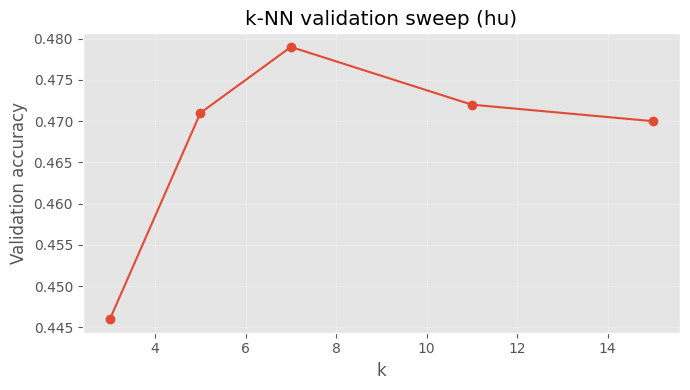


=== k-NN on tchebichef features ===


,k,val_accuracy
0,3,0.653
1,5,0.677
2,7,0.677
3,11,0.676
4,15,0.672


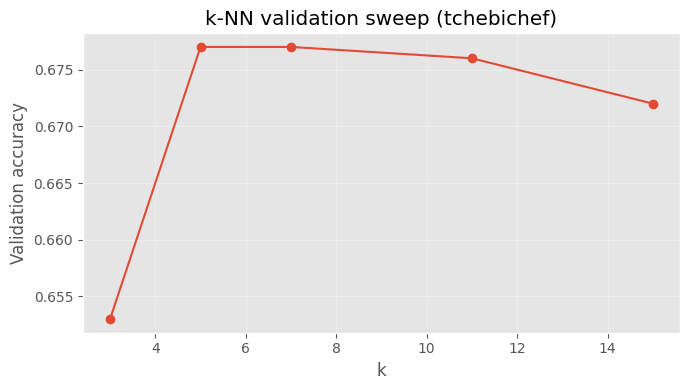


KNN summary (sorted by test accuracy):


,model,feature,selected_k,val_accuracy,test_accuracy
0,k-NN (raw),raw,5,0.904,0.9065
1,k-NN (tchebichef),tchebichef,5,0.677,0.6700
2,k-NN (hu),hu,7,0.479,0.5055


In [8]:
knn_results = {}
knn_rows = []

for feature_kind, data in feature_sets.items():
    print(f"\n=== k-NN on {feature_kind} features ===")
    result = evaluate_knn_grid(
        x_train=data["x_train"],
        y_train=splits["y_train"],
        x_val=data["x_val"],
        y_val=splits["y_val"],
        x_test=data["x_test"],
        y_test=splits["y_test"],
        k_values=config.knn_k_values,
        chunk_size=config.knn_chunk_size,
        device=device,
    )
    knn_results[feature_kind] = result

    display(result["grid"])
    plot_knn_grid(result["grid"], title=f"k-NN validation sweep ({feature_kind})")

    knn_rows.append(
        {
            "model": f"k-NN ({feature_kind})",
            "feature": feature_kind,
            "selected_k": result["best_k"],
            "val_accuracy": result["val_accuracy"],
            "test_accuracy": result["test_accuracy"],
        }
    )

knn_summary = pd.DataFrame(knn_rows).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
print("\nKNN summary (sorted by test accuracy):")
knn_summary


Best k-NN feature set: raw (k=5)
Test accuracy: 0.9065


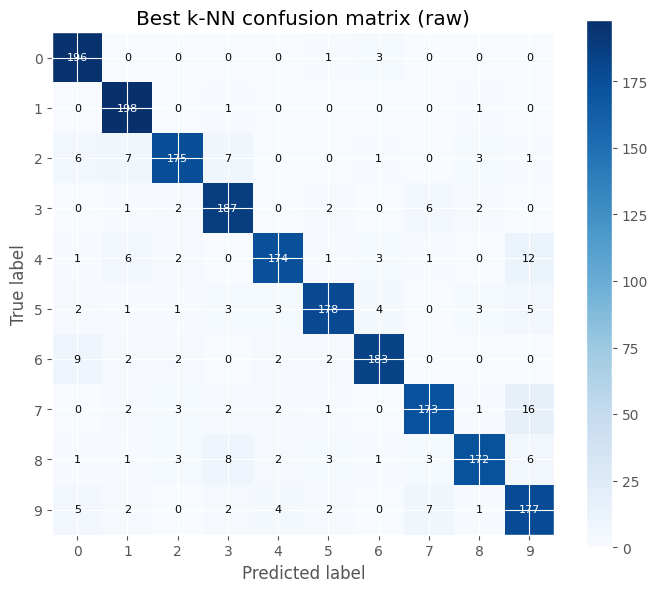

,class,precision,recall,f1_score,support
0,0,0.890909,0.9800,0.933333,200
1,1,0.900000,0.9900,0.942857,200
2,2,0.930851,0.8750,0.902062,200
3,3,0.890476,0.9350,0.912195,200
4,4,0.930481,0.8700,0.899225,200
5,5,0.936842,0.8900,0.912821,200
6,6,0.938462,0.9150,0.926582,200
7,7,0.910526,0.8650,0.887179,200
8,8,0.939891,0.8600,0.898172,200
9,9,0.815668,0.8850,0.848921,200


In [9]:
best_knn_feature = knn_summary.iloc[0]["feature"]
best_knn = knn_results[best_knn_feature]

print(f"Best k-NN feature set: {best_knn_feature} (k={best_knn['best_k']})")
print(f"Test accuracy: {best_knn['test_accuracy']:.4f}")

plot_confusion_matrix(
    best_knn["confusion_matrix"],
    title=f"Best k-NN confusion matrix ({best_knn_feature})",
)

knn_report = classification_report_from_cm(best_knn["confusion_matrix"])
knn_report


## 4) Neural Network (ANN / MLP)



=== MLP on raw features ===


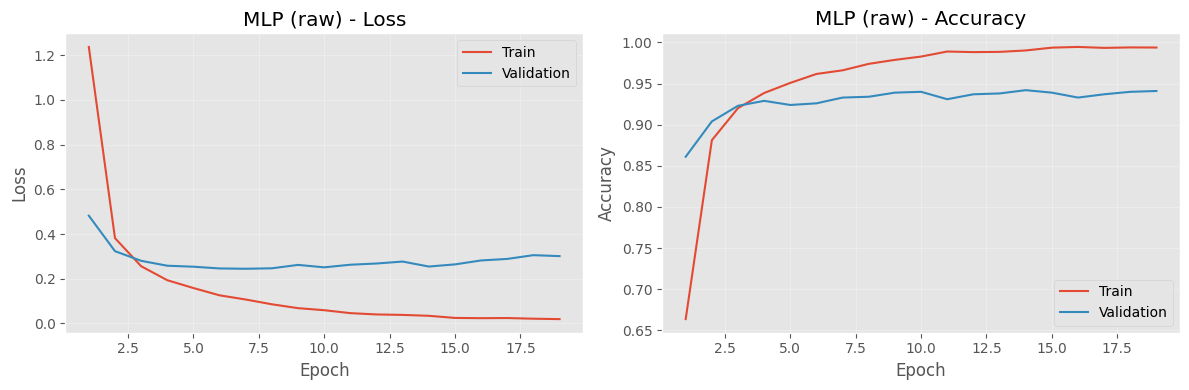


=== MLP on hu features ===


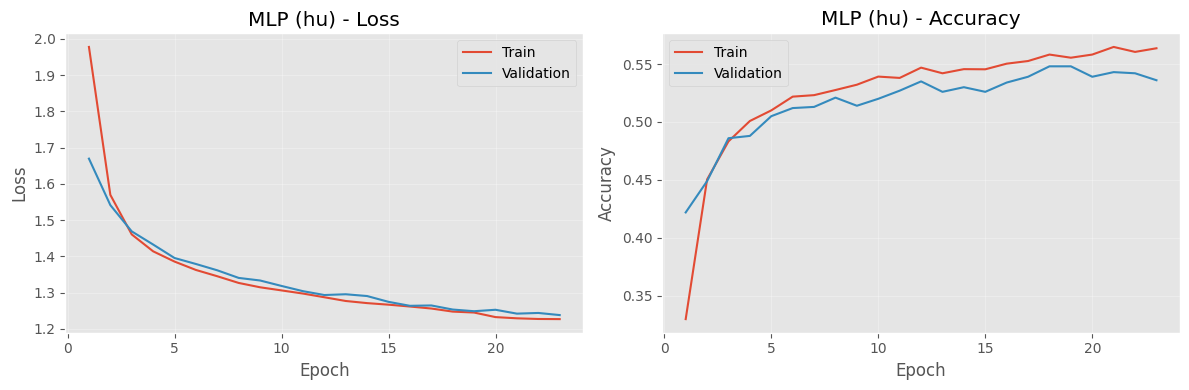


=== MLP on tchebichef features ===


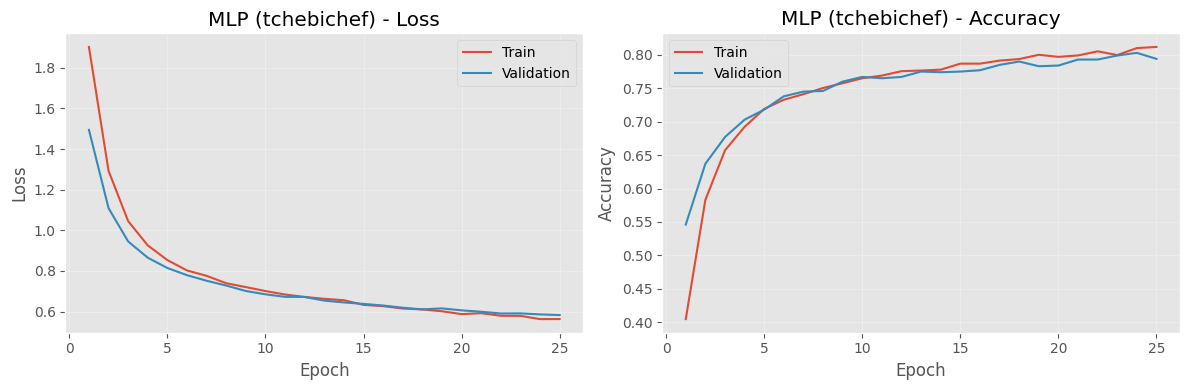


MLP summary (sorted by test accuracy):


,model,feature,selected_k,val_accuracy,test_accuracy
0,MLP (raw),raw,None,0.942,0.9455
1,MLP (tchebichef),tchebichef,None,0.803,0.8275
2,MLP (hu),hu,None,0.548,0.5760


In [10]:
mlp_results = {}
mlp_histories = {}
mlp_rows = []

for feature_kind, data in feature_sets.items():
    print(f"\n=== MLP on {feature_kind} features ===")
    model, history = train_mlp(
        x_train=data["x_train"],
        y_train=splits["y_train"],
        x_val=data["x_val"],
        y_val=splits["y_val"],
        config=config,
        device=device,
    )
    evaluation = evaluate_mlp(
        model=model,
        x_test=data["x_test"],
        y_test=splits["y_test"],
        device=device,
    )

    mlp_results[feature_kind] = {
        "model": model,
        "evaluation": evaluation,
    }
    mlp_histories[feature_kind] = history

    plot_learning_curves(history, title=f"MLP ({feature_kind})")

    best_val = history["val_accuracy"].max()
    mlp_rows.append(
        {
            "model": f"MLP ({feature_kind})",
            "feature": feature_kind,
            "selected_k": None,
            "val_accuracy": best_val,
            "test_accuracy": evaluation["test_accuracy"],
        }
    )

mlp_summary = pd.DataFrame(mlp_rows).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)
print("\nMLP summary (sorted by test accuracy):")
mlp_summary


Best MLP feature set: raw
Test accuracy: 0.9455


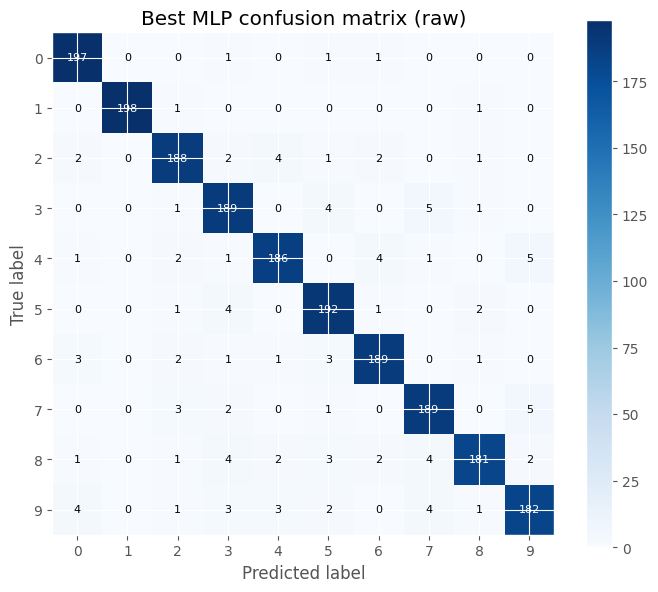

,class,precision,recall,f1_score,support
0,0,0.947115,0.9850,0.965686,200
1,1,1.000000,0.9900,0.994975,200
2,2,0.940000,0.9400,0.940000,200
3,3,0.913043,0.9450,0.928747,200
4,4,0.948980,0.9300,0.939394,200
5,5,0.927536,0.9600,0.943489,200
6,6,0.949749,0.9450,0.947368,200
7,7,0.931034,0.9450,0.937965,200
8,8,0.962766,0.9050,0.932990,200
9,9,0.938144,0.9100,0.923858,200


In [11]:
best_mlp_feature = mlp_summary.iloc[0]["feature"]
best_mlp_eval = mlp_results[best_mlp_feature]["evaluation"]

print(f"Best MLP feature set: {best_mlp_feature}")
print(f"Test accuracy: {best_mlp_eval['test_accuracy']:.4f}")

plot_confusion_matrix(
    best_mlp_eval["confusion_matrix"],
    title=f"Best MLP confusion matrix ({best_mlp_feature})",
)

mlp_report = classification_report_from_cm(best_mlp_eval["confusion_matrix"])
mlp_report


## 5) Interactive Drawing Inference (All Models)

Draw a digit and compare predictions from all trained algorithms (`k-NN` and `MLP` on each feature family).
Consensus uses weighted voting based on each model's validation accuracy.


In [ ]:
import importlib.util
import os
import subprocess
import sys

if importlib.util.find_spec("gradio") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])

import cv2 as cv
import gradio as gr
import numpy as np
import pandas as pd
import torch

from digit_pipeline import Standardizer, extract_features

required = [
    "splits",
    "knn_results",
    "mlp_results",
    "config",
    "knn_summary",
    "mlp_summary",
    "device",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run all training/evaluation cells first. Missing: {missing}")

if not isinstance(device, torch.device):
    device = torch.device(device)

feature_kinds = list(knn_results.keys())
inference_assets = {}

for fk in feature_kinds:
    x_train = extract_features(
        splits["x_train_img"], kind=fk, tchebichef_order=config.tchebichef_order
    )
    scaler = Standardizer().fit(x_train)
    x_train_std = scaler.transform(x_train).astype(np.float32)

    inference_assets[fk] = {
        "scaler": scaler,
        "x_train_t": torch.tensor(x_train_std, dtype=torch.float32, device=device),
        "y_train_t": torch.tensor(
            splits["y_train"].astype(np.int64), dtype=torch.long, device=device
        ),
        "best_k": int(knn_results[fk]["best_k"]),
        "mlp_model": mlp_results[fk]["model"].to(device).eval(),
    }


def _to_28x28(canvas):
    if isinstance(canvas, dict):
        canvas = canvas.get("composite", canvas.get("image", None))
    if canvas is None:
        raise gr.Error("Draw a digit first.")

    img = np.array(canvas)
    if img.ndim == 3:
        img = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

    if img.dtype != np.uint8:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)

    # White digit on black background (MNIST-like)
    bw = cv.threshold(img, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)[1]

    ys, xs = np.where(bw > 0)
    if len(xs) == 0:
        raise gr.Error("No digit detected. Draw a single digit (0-9).")

    crop = bw[ys.min() : ys.max() + 1, xs.min() : xs.max() + 1]

    # Scale longest side to 20 pixels, then place into 28x28 canvas
    h, w = crop.shape
    scale = 20.0 / max(h, w)
    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))
    resized = cv.resize(crop, (nw, nh), interpolation=cv.INTER_AREA)

    canvas28 = np.zeros((28, 28), dtype=np.uint8)
    y0 = (28 - nh) // 2
    x0 = (28 - nw) // 2
    canvas28[y0 : y0 + nh, x0 : x0 + nw] = resized

    # Center using center-of-mass shift
    m = cv.moments(canvas28)
    if m["m00"] > 1e-6:
        cx = m["m10"] / m["m00"]
        cy = m["m01"] / m["m00"]
        shift_x = int(round(14 - cx))
        shift_y = int(round(14 - cy))
        transform = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        canvas28 = cv.warpAffine(canvas28, transform, (28, 28), borderValue=0)

    return canvas28


@torch.no_grad()
def _knn_predict_with_conf(asset, feat_std):
    k = max(1, int(asset["best_k"]))
    q = torch.tensor(feat_std, dtype=torch.float32, device=device)
    dist = torch.cdist(q, asset["x_train_t"], p=2)
    idx = torch.topk(dist, k=k, largest=False).indices[0]
    nn_labels = asset["y_train_t"][idx]
    counts = torch.bincount(nn_labels, minlength=10).cpu().numpy()
    pred = int(np.argmax(counts))
    conf = float(counts[pred] / k)
    return pred, conf


def _weighted_consensus(df, knn_summary_df, mlp_summary_df):
    val_map = {}
    for _, row in knn_summary_df.iterrows():
        val_map[("k-NN", row["feature"])] = float(row["val_accuracy"])
    for _, row in mlp_summary_df.iterrows():
        val_map[("MLP", row["feature"])] = float(row["val_accuracy"])

    tmp = df.copy()
    tmp["val_weight"] = [
        val_map.get((algo, feat), 0.0)
        for algo, feat in zip(tmp["algorithm"], tmp["feature"])
    ]
    tmp["score"] = tmp["confidence"] * tmp["val_weight"]

    consensus = (
        tmp.groupby("prediction", as_index=False)["score"]
        .sum()
        .sort_values("score", ascending=False)
        .iloc[0]
    )
    consensus_pred = int(consensus["prediction"])
    top_row = tmp.sort_values("score", ascending=False).iloc[0]
    return consensus_pred, top_row


@torch.no_grad()
def predict_from_drawing(canvas):
    img28 = _to_28x28(canvas)
    rows = []

    for fk, asset in inference_assets.items():
        feat = extract_features(
            img28[None, :, :], kind=fk, tchebichef_order=config.tchebichef_order
        )
        feat_std = asset["scaler"].transform(feat).astype(np.float32)

        knn_pred, knn_conf = _knn_predict_with_conf(asset, feat_std)
        rows.append(
            {
                "algorithm": "k-NN",
                "feature": fk,
                "prediction": knn_pred,
                "confidence": round(knn_conf, 4),
            }
        )

        logits = asset["mlp_model"](
            torch.tensor(feat_std, dtype=torch.float32, device=device)
        )
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        mlp_pred = int(np.argmax(probs))
        mlp_conf = float(np.max(probs))
        rows.append(
            {
                "algorithm": "MLP",
                "feature": fk,
                "prediction": mlp_pred,
                "confidence": round(mlp_conf, 4),
            }
        )

    df = pd.DataFrame(rows)
    consensus_pred, top = _weighted_consensus(df, knn_summary, mlp_summary)
    df = df.sort_values(["confidence", "algorithm"], ascending=[False, True]).reset_index(drop=True)

    summary = (
        f"Top weighted model: {top['algorithm']} ({top['feature']}) -> {int(top['prediction'])} | "
        f"Weighted consensus: {consensus_pred}"
    )
    return img28, df, summary


with gr.Blocks() as demo:
    gr.Markdown("## Draw a digit (0-9) and predict with all models")

    if hasattr(gr, "Sketchpad"):
        canvas = gr.Sketchpad(type="numpy", label="Draw here")
    else:
        canvas = gr.ImageEditor(type="numpy", label="Draw here")

    btn = gr.Button("Predict")
    out_img = gr.Image(type="numpy", label="Normalized 28x28 input")
    out_tbl = gr.Dataframe(label="Predictions")
    out_txt = gr.Textbox(label="Summary")

    btn.click(predict_from_drawing, inputs=canvas, outputs=[out_img, out_tbl, out_txt])

launch_kwargs = {"share": True}
if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    launch_kwargs.update({"server_name": "0.0.0.0", "server_port": 7862})

demo.launch(**launch_kwargs)


## 6) Final Comparison


In [13]:
final_summary = pd.concat([knn_summary, mlp_summary], axis=0).reset_index(drop=True)
final_summary = final_summary.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

final_summary


,model,feature,selected_k,val_accuracy,test_accuracy
0,MLP (raw),raw,None,0.942,0.9455
1,k-NN (raw),raw,5,0.904,0.9065
2,MLP (tchebichef),tchebichef,None,0.803,0.8275
3,k-NN (tchebichef),tchebichef,5,0.677,0.6700
4,MLP (hu),hu,None,0.548,0.5760
5,k-NN (hu),hu,7,0.479,0.5055


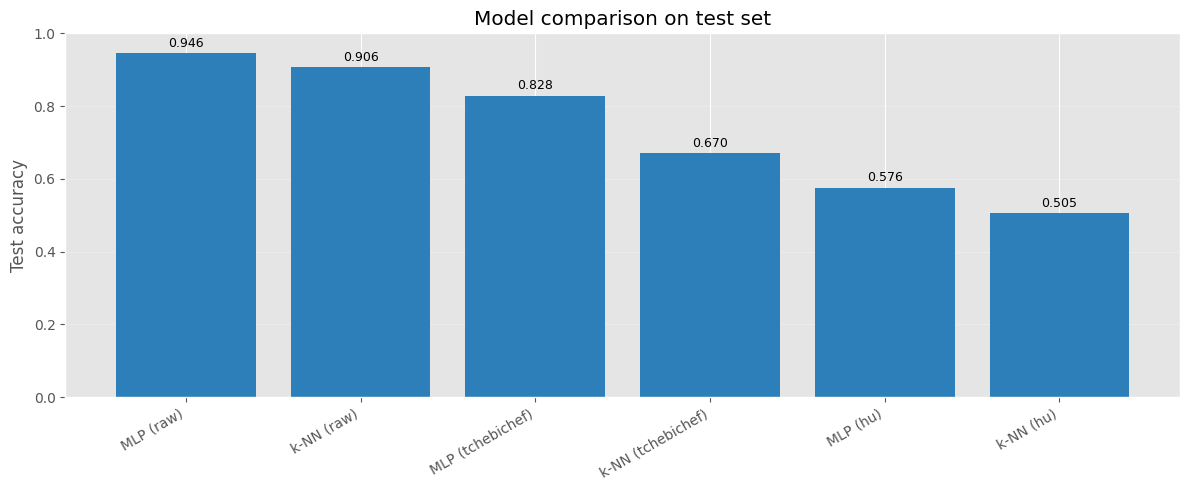

In [14]:
plot_model_comparison(final_summary, title="Model comparison on test set")

## 7) Save Results (Optional)

Save metrics and the best MLP checkpoint for reuse.


In [15]:
from pathlib import Path
import json
import torch

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

final_summary.to_csv(artifacts_dir / "model_summary.csv", index=False)

best_checkpoint = {
    "feature": best_mlp_feature,
    "config": vars(config),
    "state_dict": mlp_results[best_mlp_feature]["model"].state_dict(),
}
torch.save(best_checkpoint, artifacts_dir / "best_mlp_checkpoint.pt")

with open(artifacts_dir / "best_reports.json", "w") as f:
    json.dump(
        {
            "best_knn_feature": best_knn_feature,
            "best_knn_accuracy": float(best_knn["test_accuracy"]),
            "best_mlp_feature": best_mlp_feature,
            "best_mlp_accuracy": float(best_mlp_eval["test_accuracy"]),
        },
        f,
        indent=2,
    )

print(f"Saved artifacts to: {artifacts_dir.resolve()}")


Saved artifacts to: /kaggle/working/artifacts


## Notes

- Use `config` as the single source of experiment settings.
- Keep `train/val/test` split discipline: select models on validation only.
- Save model weights if you want to reuse them later (`state_dict`).
- Add automated checks for reproducibility and data loading if you move this into a larger project.
